<a href="https://colab.research.google.com/github/walalakhider/TP02_Fingerprint_Recognition/blob/main/tp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import structural_similarity as compare_ssim
from PIL import Image, ImageFilter, ImageOps

**Fonction de prétraitement**

In [3]:
def preprocess(image_path: str) -> np.ndarray:
    # 1️ Charger image
    img = Image.open(image_path)

    # 2️ Conversion en niveaux de gris
    img = img.convert("L")

    # 3️ Redimensionnement 300x300
    img = img.resize((300, 300))

    # 4️ Égalisation d'histogramme
    img = ImageOps.equalize(img)

    # 5️ Binarisation (seuil = 128)
    img = img.point(lambda x: 255 if x > 128 else 0)

    # 6️ Extraction des contours
    img = img.filter(ImageFilter.FIND_EDGES)

    # Conversion vers numpy array
    return np.array(img)

**Charger les images**

In [5]:
img1_path = "/content/drive/MyDrive/tp2/Fingerprint1.png"
img2_path = "/content/drive/MyDrive/tp2/Fingerprint2.png"

img1 = preprocess(img1_path)
img2 = preprocess(img2_path)

**Calcul de la similarité SSIM**

In [6]:
similarity = compare_ssim(img1, img2, data_range=255)

print("Score SSIM :", similarity)

Score SSIM : 0.21015976080715118


**Décision automatique**

In [7]:
threshold = 0.75  # seuil expérimental

if similarity >= threshold:
    print("Résultat : ACCEPTÉE")
else:
    print("Résultat : REJETÉE")

Résultat : REJETÉE


**Affichage des résultats**

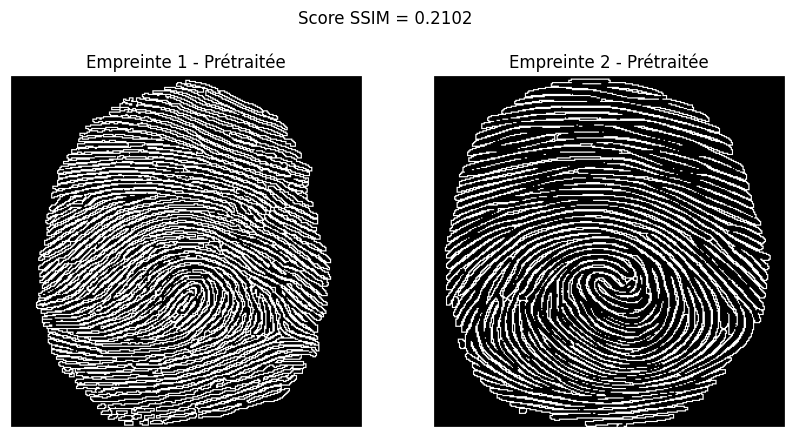

In [8]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img1, cmap='gray')
plt.title("Empreinte 1 - Prétraitée")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2, cmap='gray')
plt.title("Empreinte 2 - Prétraitée")
plt.axis("off")

plt.suptitle(f"Score SSIM = {similarity:.4f}")
plt.show()

Score SSIM : 1.0
Résultat : ACCEPTÉE


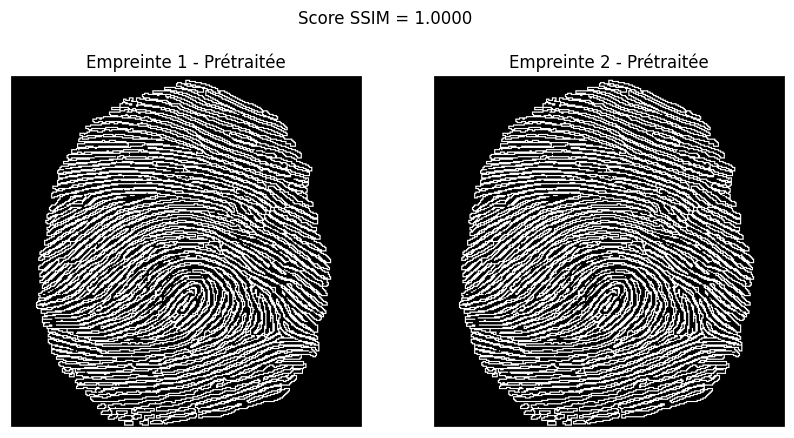

In [10]:
img1_path = "/content/drive/MyDrive/tp2/Fingerprint1.png"
img2_path = "/content/drive/MyDrive/tp2/Fingerprint1.png"

img1 = preprocess(img1_path)
img2 = preprocess(img2_path)

similarity = compare_ssim(img1, img2, data_range=255)
print("Score SSIM :", similarity)

threshold = 0.75  # seuil expérimental

if similarity >= threshold:
    print("Résultat : ACCEPTÉE")
else:
    print("Résultat : REJETÉE")

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img1, cmap='gray')
plt.title("Empreinte 1 - Prétraitée")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2, cmap='gray')
plt.title("Empreinte 2 - Prétraitée")
plt.axis("off")

plt.suptitle(f"Score SSIM = {similarity:.4f}")
plt.show()